# PA1 — Fundamentos de Machine Learning (ISIL · 30506)
## Predicción de abandono de clientes (*churn*) en una empresa de telecomunicaciones

| | |
|---|---|
| **Estudiante** | _(escribe tu nombre)_ |
| **Carrera** | Ciencia de Datos (CCDT) |
| **Docente** | _(nombre del docente)_ |
| **Entorno** | Google Colab |
| **Datos** | Telco Customer Churn (IBM), cargado desde GitHub |

**Objetivo del PA1:** familiarizarse con Google Colab, cargar datos desde GitHub, realizar un análisis exploratorio (EDA) con al menos 5 gráficas, procesar los datos con pandas, entrenar un modelo de Machine Learning, evaluarlo con métricas y guardarlo para su revisión.

El cuaderno sigue la **canalización de ML** vista en clase (S04):
1. Formulación del problema → 2. Recopilación (carga desde GitHub) → 3. Evaluación de datos (EDA) → 4. Diseño de características (procesamiento) → 5. Selección y entrenamiento del modelo → 6. Evaluación del modelo → 7. Guardado del modelo (preparación para implementación)

## 1. Formulación del problema

**Problema de negocio.** Una empresa de telecomunicaciones pierde clientes cada mes. Retener a un cliente cuesta mucho menos que conseguir uno nuevo, así que quiere saber **qué clientes tienen alta probabilidad de irse** para ofrecerles una promoción de retención antes de que cancelen.

Aplicamos las preguntas de la S04:

| Pregunta | Respuesta |
|---|---|
| ¿Cómo se hace actualmente? | El área comercial reacciona cuando el cliente ya pidió la baja. |
| ¿Cómo se medirá el éxito? | Reducir la tasa de abandono (por ejemplo, un 10 % en 6 meses) con campañas dirigidas. |
| ¿Es un problema de ML? | Sí: hay datos históricos con la respuesta conocida (si el cliente se fue o no). |
| ¿Supervisado o no supervisado? | **Supervisado**, porque los datos están etiquetados (`Churn` = Yes/No). |
| ¿Cuál es el objetivo a predecir? | `Churn` → **clasificación binaria** (1 = se va, 0 = se queda). |
| ¿Solución más simple? | Predecir siempre "no se va" (modelo base). Nuestro modelo debe superarla. |

**Métrica del modelo alineada con el negocio (S06):** dejar escapar a un cliente que se va (**falso negativo**) cuesta más que ofrecerle una promoción a alguien que se iba a quedar (**falso positivo**). Por eso priorizamos la **sensibilidad (recall)** y usamos el **AUC-ROC** para comparar modelos sin depender del umbral.

## 2. Configuración del entorno (Google Colab)
Importamos las librerías que usaremos en todo el cuaderno. Colab ya las trae instaladas.

In [5]:
# Librerías de manejo de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning (scikit-learn)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay)

# Guardado del modelo
import joblib, json, sklearn

# Configuración general
SEMILLA = 42                                  # para que los resultados sean reproducibles
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)    # mostrar todas las columnas
print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| seaborn", sns.__version__)

pandas 2.2.3 | scikit-learn 1.6.1 | seaborn 0.13.2


## 3. Carga de datos desde GitHub

Para leer un CSV desde GitHub se usa la URL **raw** (texto plano), no la página normal del repositorio:
1. Sube el archivo `Telco-Customer-Churn.csv` a tu repositorio de GitHub.
2. Abre el archivo en GitHub y pulsa el botón **Raw**.
3. Copia la URL (empieza con `https://raw.githubusercontent.com/...`) y pégala en la variable `URL_DATOS`.

Mientras tanto, el cuaderno usa la copia pública del repositorio de IBM.

In [6]:
# URL "raw" del archivo en GitHub (reemplázala por la de TU repositorio)
URL_DATOS = "https://raw.githubusercontent.com/iamisaacmachinelearning-eng/PA1-Fundamentos-ML/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(URL_DATOS)     # pandas descarga y lee el CSV directamente desde la URL
print("Datos cargados correctamente:", df.shape[0], "filas y", df.shape[1], "columnas")
df.head()

Datos cargados correctamente: 7043 filas y 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Análisis exploratorio de datos (EDA)

### 4.1 Campos generales
Revisamos tamaño, tipos, estadísticas descriptivas, faltantes, duplicados y valores únicos antes de limpiar (S05: "antes de ejecutar estadísticas, asegurar que los datos estén en el formato correcto").

In [7]:
# Dimensiones y últimas filas
print("Dimensiones (filas, columnas):", df.shape)
df.tail(3)

Dimensiones (filas, columnas): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
# Estructura: nombre de columnas, cantidad de no nulos y tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [10]:
# Estadísticas de las variables categóricas (texto): cantidad, valores únicos, moda y su frecuencia
df.describe(include=["object", "string"]).T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [11]:
# Valores faltantes: nulos "reales" y celdas con solo espacios en blanco
nulos = df.isnull().sum()
blancos = (df.select_dtypes(include=["object", "string"]).apply(lambda c: c.str.strip() == "")).sum()
resumen = pd.DataFrame({"nulos": nulos, "en_blanco": blancos}).fillna(0).astype(int)
print("Total de nulos:", nulos.sum(), "| Total de celdas en blanco:", blancos.sum())
resumen[(resumen.nulos > 0) | (resumen.en_blanco > 0)]

Total de nulos: 0 | Total de celdas en blanco: 11


,nulos,en_blanco
TotalCharges,0,11


**Hallazgo:** `TotalCharges` es de tipo texto (`object`) aunque debería ser numérica, porque tiene 11 celdas con un espacio en blanco. `df.isnull()` no las detecta; hay que convertir la columna a número en el procesamiento.

In [12]:
# Duplicados: filas completas repetidas y identificadores repetidos
print("Filas duplicadas:", df.duplicated().sum())
print("customerID duplicados:", df["customerID"].duplicated().sum())

# Cantidad de valores únicos por columna (ayuda a decidir la codificación)
df.nunique().sort_values()

Filas duplicadas: 0
customerID duplicados: 0


,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3


In [13]:
# Valores posibles de cada variable categórica (excepto el ID)
for col in df.select_dtypes(include=["object", "string"]).columns.drop(["customerID", "TotalCharges"]):
    print(f"{col:17s} → {df[col].unique().tolist()}")

gender            → ['Female', 'Male']
Partner           → ['Yes', 'No']
Dependents        → ['No', 'Yes']
PhoneService      → ['No', 'Yes']
MultipleLines     → ['No phone service', 'No', 'Yes']
InternetService   → ['DSL', 'Fiber optic', 'No']
OnlineSecurity    → ['No', 'Yes', 'No internet service']
OnlineBackup      → ['Yes', 'No', 'No internet service']
DeviceProtection  → ['No', 'Yes', 'No internet service']
TechSupport       → ['No', 'Yes', 'No internet service']
StreamingTV       → ['No', 'Yes', 'No internet service']
StreamingMovies   → ['No', 'Yes', 'No internet service']
Contract          → ['Month-to-month', 'One year', 'Two year']
PaperlessBilling  → ['Yes', 'No']
PaymentMethod     → ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn             → ['No', 'Yes']


In [14]:
# Balance de la variable objetivo
conteo = df["Churn"].value_counts()
porcentaje = df["Churn"].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({"clientes": conteo, "%": porcentaje})

,clientes,%
Churn,,
No,5174,73.46
Yes,1869,26.54


**Hallazgos de los campos generales:**
- 7043 clientes y 21 columnas; sin filas ni IDs duplicados.
- 3 variables numéricas (`SeniorCitizen`, `tenure`, `MonthlyCharges`), aunque `SeniorCitizen` es en realidad binaria (0/1), y `TotalCharges` debe convertirse a número.
- Muchas variables categóricas con 2 a 4 valores: se podrán codificar con mapeo binario, ordinal u one-hot.
- Varias columnas tienen la categoría "No internet service" o "No phone service", que en la práctica significa "No".
- La clase está **desbalanceada**: ~26,5 % de clientes se va. La exactitud sola puede engañar; por eso usaremos sensibilidad, precisión, F1 y AUC.

### 4.2 Visualizaciones

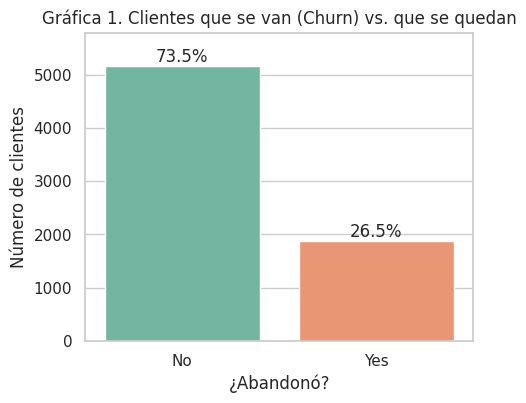

In [15]:
# Gráfica 1 — Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", hue="Churn", legend=False, ax=ax)
for barra in ax.patches:                                   # porcentaje sobre cada barra
    ax.annotate(f"{barra.get_height() / len(df):.1%}",
                (barra.get_x() + barra.get_width() / 2, barra.get_height()), ha="center", va="bottom")
ax.set_title("Gráfica 1. Clientes que se van (Churn) vs. que se quedan")
ax.set_xlabel("¿Abandonó?"); ax.set_ylabel("Número de clientes")
ax.set_ylim(0, conteo_max := df["Churn"].value_counts().max() * 1.12)
plt.show()

La clase positiva (Yes) es minoritaria: 1 de cada 4 clientes aproximadamente.

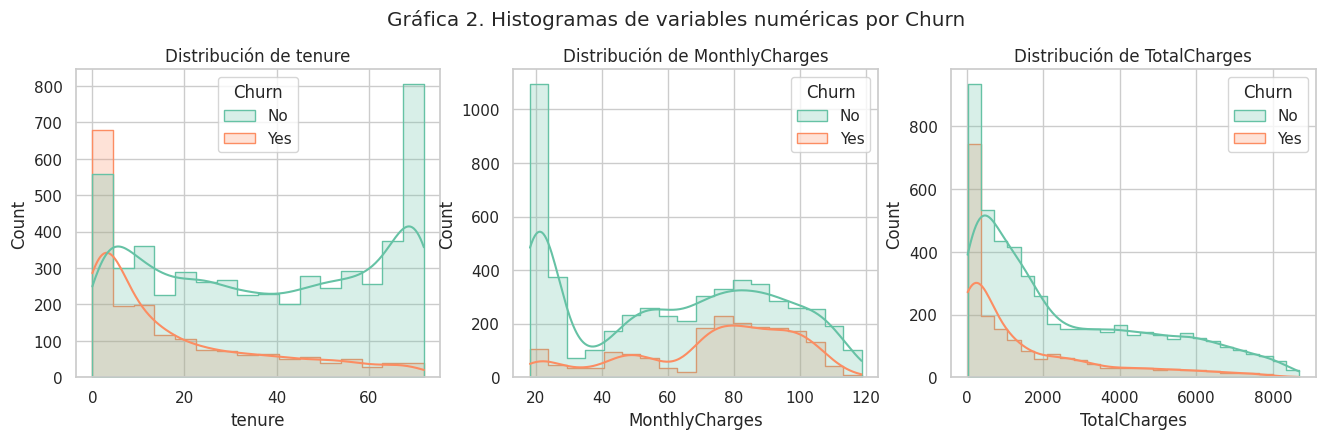

In [16]:
# Gráfica 2 — Histogramas de las variables numéricas, separadas por Churn
df_graf = df.copy()
df_graf["TotalCharges"] = pd.to_numeric(df_graf["TotalCharges"], errors="coerce")  # solo para graficar

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df_graf, x=col, hue="Churn", kde=True, element="step", ax=ax)
    ax.set_title(f"Distribución de {col}")
fig.suptitle("Gráfica 2. Histogramas de variables numéricas por Churn", y=1.03)
plt.show()

- `tenure` (meses como cliente) es bimodal: muchos clientes nuevos y muchos muy antiguos. Los que se van se concentran en los **primeros meses**.
- `MonthlyCharges`: los que se van tienden a pagar cargos mensuales **más altos**.
- `TotalCharges` tiene **sesgo a la derecha** (cola larga), lógico porque es acumulado en el tiempo.

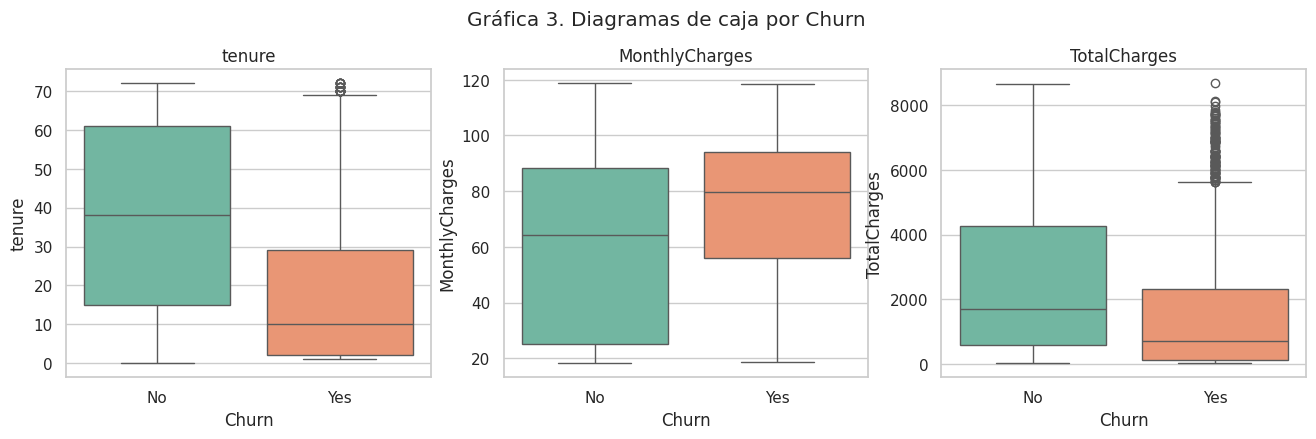

In [17]:
# Gráfica 3 — Diagramas de caja para detectar valores atípicos (outliers)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df_graf, x="Churn", y=col, hue="Churn", legend=False, ax=ax)
    ax.set_title(col)
fig.suptitle("Gráfica 3. Diagramas de caja por Churn", y=1.03)
plt.show()

No aparecen atípicos extremos en las cajas generales; los puntos fuera de los bigotes en `TotalCharges` del grupo "Yes" son clientes que se fueron después de mucho tiempo, es decir, casos reales y no errores. Lo confirmaremos con la regla IQR en el procesamiento.

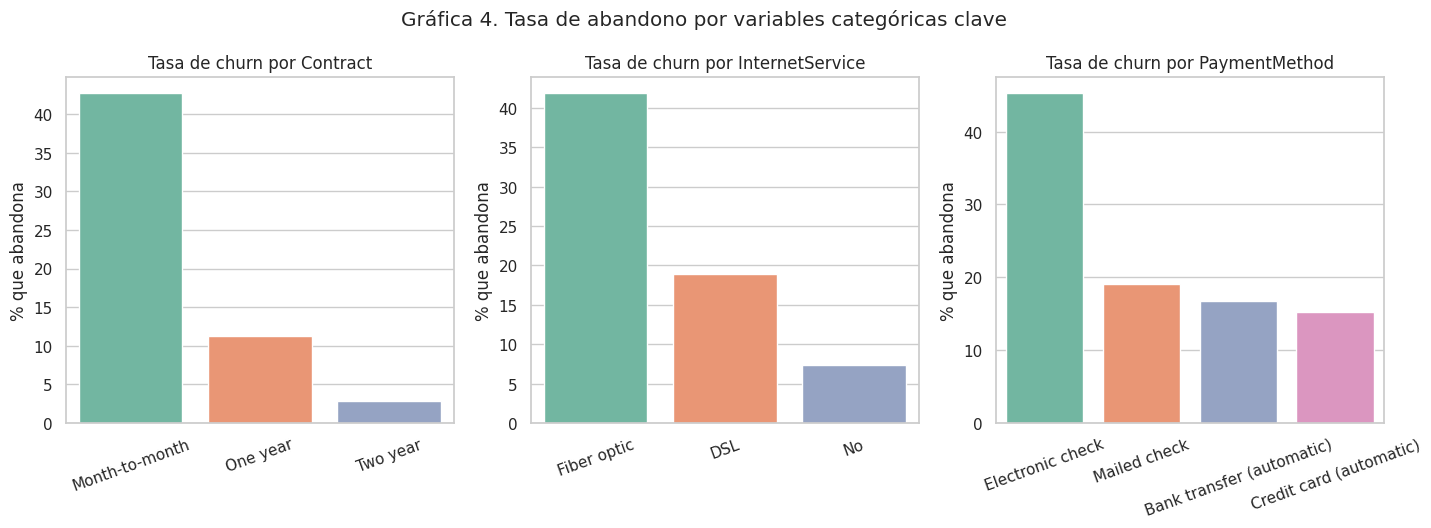

In [18]:
# Gráfica 4 — Tasa de abandono según tipo de contrato, servicio de internet y método de pago
df_graf["churn_num"] = (df_graf["Churn"] == "Yes").astype(int)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    tasa = df_graf.groupby(col)["churn_num"].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.index, y=tasa.values * 100, hue=tasa.index, legend=False, ax=ax)
    ax.set_title(f"Tasa de churn por {col}"); ax.set_ylabel("% que abandona"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Gráfica 4. Tasa de abandono por variables categóricas clave", y=1.03)
plt.show()

- Contrato **mes a mes**: ~43 % abandona, frente a ~3 % con contrato de dos años. Es la variable con mayor diferencia.
- **Fibra óptica** tiene más abandono que DSL, posiblemente por precio o calidad percibida.
- El pago con **cheque electrónico** se asocia al mayor abandono.

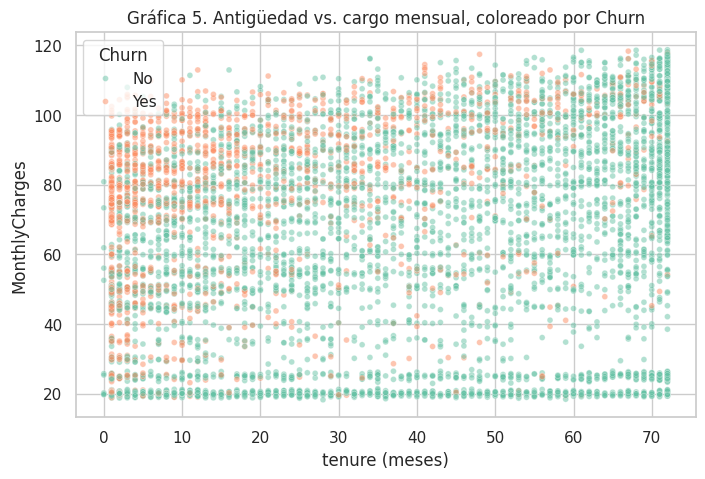

In [19]:
# Gráfica 5 — Relación entre antigüedad y cargo mensual (dispersión multivariable)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_graf, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5, s=18, ax=ax)
ax.set_title("Gráfica 5. Antigüedad vs. cargo mensual, coloreado por Churn")
ax.set_xlabel("tenure (meses)"); ax.set_ylabel("MonthlyCharges")
plt.show()

El abandono se concentra en la zona de **poca antigüedad y cargo mensual alto** (esquina superior izquierda).

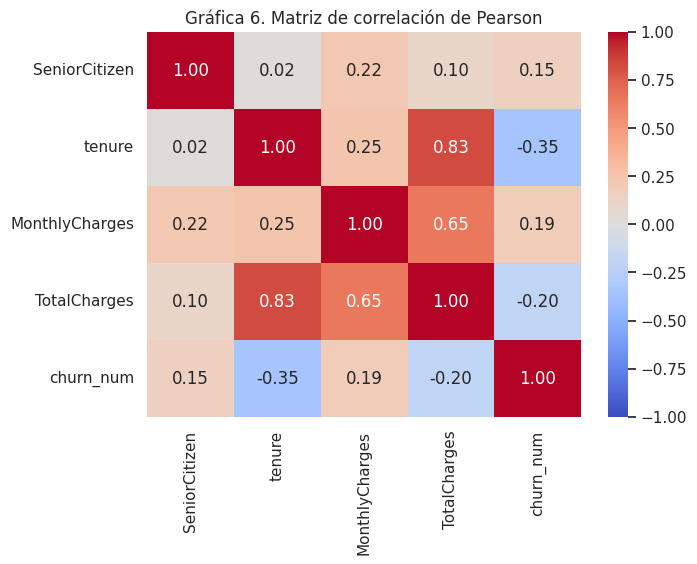

In [20]:
# Gráfica 6 — Mapa de calor de la matriz de correlación (variables numéricas + objetivo)
corr = df_graf[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "churn_num"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Gráfica 6. Matriz de correlación de Pearson")
plt.show()

- `tenure` y `TotalCharges` tienen correlación alta (~0,83): son en parte **redundantes**, porque el total es aproximadamente cargo mensual × meses.
- `tenure` tiene correlación **negativa** con el abandono (a más antigüedad, menos churn); `MonthlyCharges`, positiva y débil.
- Recordatorio: correlación no implica causalidad.

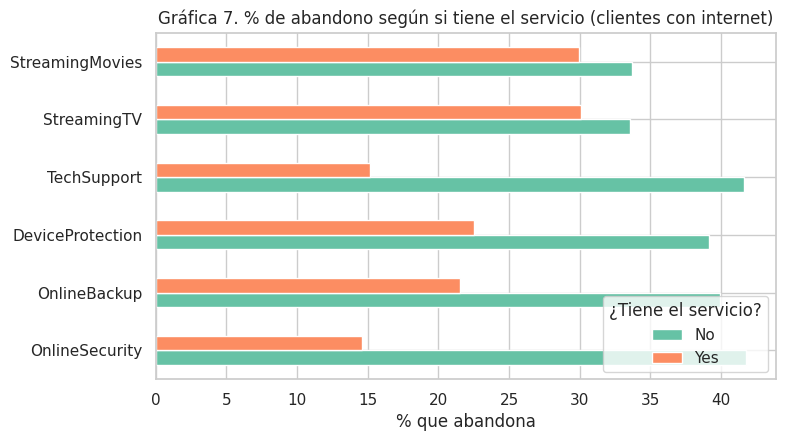

In [21]:
# Gráfica 7 — Abandono según servicios adicionales contratados
servicios = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
tasas = pd.DataFrame({s: df_graf[df_graf["InternetService"] != "No"].groupby(s)["churn_num"].mean() for s in servicios}).T * 100
tasas.plot(kind="barh", figsize=(8, 4.5))
plt.title("Gráfica 7. % de abandono según si tiene el servicio (clientes con internet)")
plt.xlabel("% que abandona"); plt.legend(title="¿Tiene el servicio?", loc="lower right")
plt.show()

Los clientes **sin seguridad en línea ni soporte técnico** abandonan mucho más; los servicios de streaming casi no marcan diferencia.

## 5. Procesamiento de datos con pandas

Decisiones basadas en el EDA:
1. Eliminar `customerID` (identificador, no aporta patrón).
2. Convertir `TotalCharges` a número y tratar sus faltantes.
3. Estandarizar categorías inconsistentes ("No internet service" → "No").
4. Revisar atípicos con la regla IQR.
5. Crear nuevas características.
6. Codificar las variables categóricas (binaria, ordinal y one-hot).

In [22]:
datos = df.copy()                               # trabajamos sobre una copia para conservar el original

# 5.1 Eliminar el identificador
datos = datos.drop(columns="customerID")

# 5.2 Convertir TotalCharges a número: los espacios en blanco pasan a NaN
datos["TotalCharges"] = pd.to_numeric(datos["TotalCharges"], errors="coerce")
faltantes = datos[datos["TotalCharges"].isnull()]
print("Filas con TotalCharges faltante:", len(faltantes))
faltantes[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Filas con TotalCharges faltante: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


**¿Por qué faltan? (S05: preguntar por el mecanismo antes de imputar).** Las 11 filas tienen `tenure = 0`: son clientes que recién se afiliaron y todavía no tienen facturación acumulada. No es un dato perdido al azar; su valor lógico es **0**. Por eso imputamos 0 en lugar de la media (que inventaría un gasto que no existe).

In [23]:
datos["TotalCharges"] = datos["TotalCharges"].fillna(0)
print("Nulos restantes en todo el dataset:", datos.isnull().sum().sum())

# 5.3 Estandarizar categorías: "No internet service" y "No phone service" significan "No"
datos = datos.replace({"No internet service": "No", "No phone service": "No"})
print(datos["OnlineSecurity"].unique(), datos["MultipleLines"].unique())

Nulos restantes en todo el dataset: 0
['No' 'Yes'] ['No' 'Yes']


In [ ]:
# 5.4 Detección de atípicos con la regla IQR: fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    q1, q3 = datos[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_atipicos = ((datos[col] < lim_inf) | (datos[col] > lim_sup)).sum()
    print(f"{col:15s} límites [{lim_inf:8.2f}, {lim_sup:8.2f}] → atípicos: {n_atipicos}")

tenure          límites [  -60.00,   124.00] → atípicos: 0
MonthlyCharges  límites [  -46.02,   171.38] → atípicos: 0
TotalCharges    límites [-4683.52,  8868.67] → atípicos: 0


No hay atípicos según IQR, así que no se elimina ni transforma ningún registro.

In [24]:
# 5.5 Diseño de características (feature engineering)
servicios_extra = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
datos["num_servicios_extra"] = (datos[servicios_extra] == "Yes").sum(axis=1)   # cuántos servicios adicionales tiene
datos["cliente_nuevo"] = (datos["tenure"] <= 6).astype(int)                     # 6 meses o menos
datos[["tenure", "num_servicios_extra", "cliente_nuevo"]].head()

,tenure,num_servicios_extra,cliente_nuevo
0,1,1,1
1,34,2,0
2,2,2,1
3,45,3,0
4,2,0,1


In [25]:
# 5.6 Codificación de variables categóricas

# a) Variables binarias Yes/No → 1/0 (incluye la variable objetivo)
binarias = ["Partner", "Dependents", "PhoneService", "MultipleLines", "PaperlessBilling", "Churn"] + servicios_extra
for col in binarias:
    datos[col] = datos[col].map({"Yes": 1, "No": 0})
datos["gender"] = datos["gender"].map({"Male": 1, "Female": 0})

# b) Codificación ORDINAL para Contract, porque tiene un orden natural de compromiso
orden_contrato = {"Month-to-month": 0, "One year": 1, "Two year": 2}
datos["Contract"] = datos["Contract"].map(orden_contrato)

# c) Codificación ONE-HOT para variables nominales sin orden (drop_first evita columnas redundantes)
datos = pd.get_dummies(datos, columns=["InternetService", "PaymentMethod"], drop_first=True, dtype=int)

print("Dimensiones después del procesamiento:", datos.shape)
print("¿Quedan columnas de texto?:", datos.select_dtypes(include=["object", "string"]).columns.tolist())
datos.head()

Dimensiones después del procesamiento: (7043, 25)
¿Quedan columnas de texto?: []


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,num_servicios_extra,cliente_nuevo,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0,1,1,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0,2,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1,2,1,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0,3,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1,0,1,1,0,0,1,0


In [26]:
# Verificación final: tipos, nulos y balance del objetivo ya codificado
print(datos.dtypes.value_counts())
print("Nulos:", datos.isnull().sum().sum())
print(datos["Churn"].value_counts(normalize=True).round(3))

int64      23
float64     2
Name: count, dtype: int64
Nulos: 0
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 6. Selección y entrenamiento del modelo

**Modelo elegido: Random Forest (bosque aleatorio).** Es un conjunto de árboles de decisión que votan; lo elegimos porque:
- funciona bien con datos tabulares mezclados (binarios, ordinales, numéricos) sin necesidad de escalar;
- es robusto al sobreajuste comparado con un solo árbol;
- permite ver la **importancia de las características**, útil para explicar el modelo al negocio;
- con `class_weight="balanced"` compensa el desbalance de clases.

**División de datos (S06):** 80 % entrenamiento y 20 % prueba, **estratificada** para mantener el ~26 % de churn en ambos conjuntos y **mezclada** con semilla fija. En lugar de un conjunto de validación separado usamos **validación cruzada de 5 iteraciones** sobre el entrenamiento. El conjunto de prueba solo se usa al final.

In [33]:
X = datos.drop(columns="Churn")      # características
y = datos["Churn"]                   # objetivo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, shuffle=True, random_state=SEMILLA)

print("Entrenamiento:", X_train.shape, "| churn =", round(y_train.mean(), 3))
print("Prueba:       ", X_test.shape, "| churn =", round(y_test.mean(), 3))

Entrenamiento: (5634, 24) | churn = 0.265
Prueba:        (1409, 24) | churn = 0.265


In [34]:
# Modelo base (la "solución más simple"): predice siempre la clase mayoritaria
base = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

# Modelo elegido con sus hiperparámetros
modelo = RandomForestClassifier(
    n_estimators=300,          # número de árboles
    max_depth=10,              # profundidad máxima: limita el sobreajuste
    min_samples_leaf=5,        # mínimo de clientes por hoja
    class_weight="balanced",   # da más peso a la clase minoritaria (churn)
    random_state=SEMILLA,
    n_jobs=-1)

# Validación cruzada estratificada de 5 iteraciones sobre el entrenamiento
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
auc_cv = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="roc_auc")
recall_cv = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="recall")
print("AUC por iteración:   ", auc_cv.round(3), "→ media", auc_cv.mean().round(3), "±", auc_cv.std().round(3))
print("Recall por iteración:", recall_cv.round(3), "→ media", recall_cv.mean().round(3))

# Entrenamiento final con todo el conjunto de entrenamiento
modelo.fit(X_train, y_train)
print("\nModelo entrenado ✔")

AUC por iteración:    [0.838 0.834 0.845 0.852 0.861] → media 0.846 ± 0.01
Recall por iteración: [0.766 0.689 0.753 0.773 0.739] → media 0.744

Modelo entrenado ✔


La desviación estándar pequeña entre iteraciones indica que el modelo es **estable** y no depende de una partición particular.

## 7. Evaluación del modelo

Evaluamos con el **conjunto de prueba** (datos que el modelo nunca vio).

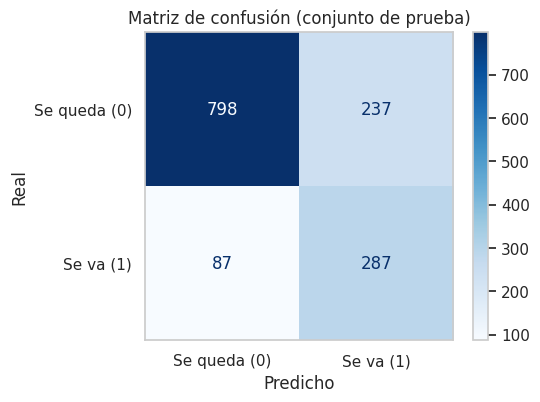

VP = 287 (se iban y los detectamos)      FN = 87 (se iban y NO los detectamos)
FP = 237 (se quedaban y dijimos que se iban)   VN = 798 (se quedaban y acertamos)


In [35]:
y_pred = modelo.predict(X_test)                    # clase predicha (umbral 0.5)
y_proba = modelo.predict_proba(X_test)[:, 1]       # probabilidad de churn

# Matriz de confusión: en scikit-learn las filas son el valor REAL y las columnas el PREDICHO
vn, fp, fn, vp = confusion_matrix(y_test, y_pred).ravel()
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Se queda (0)", "Se va (1)"],
                                        cmap="Blues", ax=ax)
ax.set_title("Matriz de confusión (conjunto de prueba)")
ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.grid(False)
plt.show()
print(f"VP = {vp} (se iban y los detectamos)      FN = {fn} (se iban y NO los detectamos)")
print(f"FP = {fp} (se quedaban y dijimos que se iban)   VN = {vn} (se quedaban y acertamos)")

In [36]:
# Métricas de clasificación (fórmulas vistas en la S06)
metricas = {
    "exactitud (accuracy)":      accuracy_score(y_test, y_pred),          # (VP+VN)/total
    "precisión (precision)":     precision_score(y_test, y_pred),         # VP/(VP+FP)
    "sensibilidad (recall)":     recall_score(y_test, y_pred),            # VP/(VP+FN)
    "especificidad":             vn / (vn + fp),                          # VN/(VN+FP)
    "F1":                        f1_score(y_test, y_pred),                # 2·P·R/(P+R)
    "AUC-ROC":                   roc_auc_score(y_test, y_proba),
}
# Comparación con el modelo base
y_base = base.predict(X_test)
comparacion = pd.DataFrame({
    "Random Forest": metricas,
    "Modelo base": {"exactitud (accuracy)": accuracy_score(y_test, y_base),
                    "precisión (precision)": precision_score(y_test, y_base, zero_division=0),
                    "sensibilidad (recall)": recall_score(y_test, y_base),
                    "especificidad": 1.0,
                    "F1": f1_score(y_test, y_base),
                    "AUC-ROC": 0.5}}).round(3)
comparacion

,Random Forest,Modelo base
exactitud (accuracy),0.770,0.735
precisión (precision),0.548,0.000
sensibilidad (recall),0.767,0.000
especificidad,0.771,1.000
F1,0.639,0.000
AUC-ROC,0.846,0.500


El modelo base obtiene una exactitud engañosamente alta (~73 %) sin detectar a **ningún** cliente que se va (sensibilidad 0). Esto demuestra por qué no basta mirar la exactitud cuando hay clases desbalanceadas.

In [37]:
# Reporte completo por clase
print(classification_report(y_test, y_pred, target_names=["Se queda", "Se va"], digits=3))

              precision    recall  f1-score   support

    Se queda      0.902     0.771     0.831      1035
       Se va      0.548     0.767     0.639       374

    accuracy                          0.770      1409
   macro avg      0.725     0.769     0.735      1409
weighted avg      0.808     0.770     0.780      1409



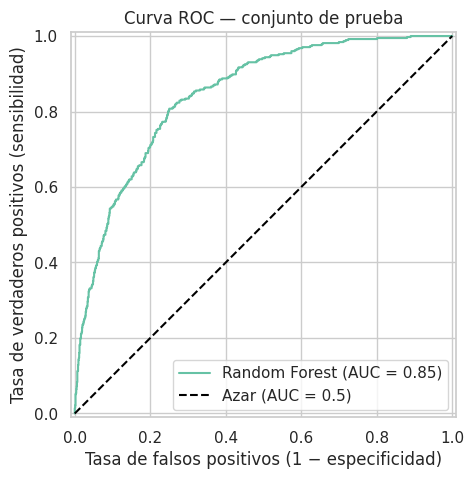

In [38]:
# Curva ROC: sensibilidad (TVP) vs. 1 - especificidad (TFP) para todos los umbrales
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.5)")
ax.set_title("Curva ROC — conjunto de prueba")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)"); ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)"); ax.legend()
plt.show()

In [39]:
# Análisis de umbrales (S06): cambiar el umbral cambia el equilibrio entre sensibilidad y especificidad
filas = []
for u in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_u = (y_proba >= u).astype(int)
    tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test, pred_u).ravel()
    filas.append({"umbral": u, "sensibilidad": tp_u / (tp_u + fn_u), "especificidad": tn_u / (tn_u + fp_u),
                  "precisión": tp_u / (tp_u + fp_u), "clientes contactados": tp_u + fp_u, "fugas no detectadas": fn_u})
pd.DataFrame(filas).round(3)

,umbral,sensibilidad,especificidad,precisión,clientes contactados,fugas no detectadas
0,0.3,0.885,0.610,0.450,735,43
1,0.4,0.832,0.708,0.507,613,63
2,0.5,0.767,0.771,0.548,524,87
3,0.6,0.628,0.846,0.596,394,139
4,0.7,0.500,0.914,0.678,276,187


Bajar el umbral detecta más clientes que se van (↑ sensibilidad), a costa de contactar a más clientes que se iban a quedar (↓ especificidad). La elección final depende del costo de la promoción frente al valor de un cliente retenido; mantenemos el umbral por defecto de 0,5.

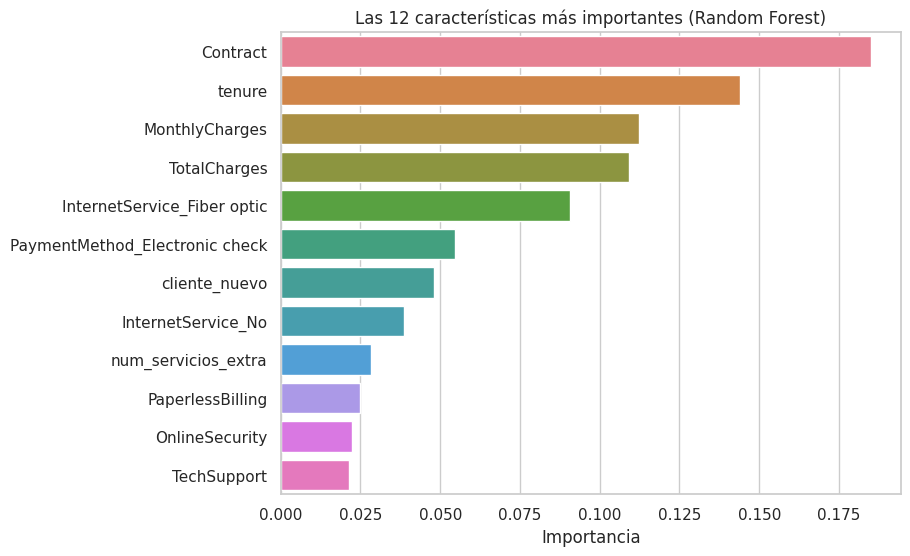

In [40]:
# Importancia de las características: qué variables usa más el modelo
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importancias.head(12).values, y=importancias.head(12).index, hue=importancias.head(12).index,
            legend=False, ax=ax)
ax.set_title("Las 12 características más importantes (Random Forest)"); ax.set_xlabel("Importancia"); ax.set_ylabel("")
plt.show()

## 8. Guardado del modelo para revisión

Guardamos con `joblib`:
- `modelo_churn_rf.joblib`: el modelo entrenado;
- `columnas_modelo.json`: el orden de las columnas que espera el modelo;
- `metricas_modelo.json`: las métricas obtenidas;
- `telco_procesado.csv`: el dataset ya procesado.

Luego se verifica que el modelo guardado se pueda cargar y predecir, y se descargan los archivos.

In [42]:
joblib.dump(modelo, "modelo_churn_rf.joblib", compress=3)

with open("columnas_modelo.json", "w") as f:
    json.dump(list(X.columns), f, indent=2)

with open("metricas_modelo.json", "w", encoding="utf-8") as f:
    json.dump({"modelo": "RandomForestClassifier", "hiperparametros": modelo.get_params(),
               "metricas_prueba": {k: round(float(v), 4) for k, v in metricas.items()},
               "auc_validacion_cruzada": round(float(auc_cv.mean()), 4),
               "scikit_learn": sklearn.__version__}, f, indent=2, ensure_ascii=False)

datos.to_csv("telco_procesado.csv", index=False)
print("Archivos guardados ✔")

Archivos guardados ✔


In [43]:
# Verificación: cargar el modelo guardado y predecir con él
modelo_cargado = joblib.load("modelo_churn_rf.joblib")
columnas = json.load(open("columnas_modelo.json"))
muestra = X_test[columnas].head(5)
print("Predicciones del modelo cargado:", modelo_cargado.predict(muestra))
print("Probabilidad de churn:          ", modelo_cargado.predict_proba(muestra)[:, 1].round(3))
print("Valores reales:                 ", y_test.head(5).values)
print("¿Mismo resultado que el original?:", (modelo_cargado.predict(X_test) == y_pred).all())

Predicciones del modelo cargado: [0 1 0 1 0]
Probabilidad de churn:           [0.031 0.828 0.124 0.539 0.037]
Valores reales:                  [0 0 0 0 0]
¿Mismo resultado que el original?: True


In [45]:
# Descargar los archivos a tu computadora (solo funciona dentro de Google Colab)
try:
    from google.colab import files
    for archivo in ["modelo_churn_rf.joblib", "columnas_modelo.json", "metricas_modelo.json", "telco_procesado.csv"]:
        files.download(archivo)
except ImportError:
    print("No estás en Colab: los archivos quedaron en la carpeta actual.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Conclusiones

1. **Datos:** el dataset (7043 clientes, 21 columnas) llegó casi limpio; el único problema real fue `TotalCharges` guardado como texto con 11 blancos, que correspondían a clientes nuevos (`tenure = 0`) y se imputaron con 0 según su significado de negocio, no con la media.
2. **EDA:** el abandono se concentra en clientes con **contrato mes a mes** (~43 % frente a ~3 % en contratos de dos años), **poca antigüedad**, **cargos mensuales altos**, **fibra óptica**, pago con **cheque electrónico** y **sin seguridad en línea ni soporte técnico**.
3. **Modelo:** el Random Forest obtuvo en prueba un **AUC de 0,846**, igual al de la validación cruzada (0,846 ± 0,01), señal de que **no hay sobreajuste** y generaliza a datos nuevos.
4. **Métricas:** detecta el **76,7 % de los clientes que se van** (sensibilidad) con especificidad de 77,1 %. La precisión (54,8 %) indica que aproximadamente la mitad de los clientes contactados no se iba a ir; es un costo aceptable si la promoción es barata frente al valor de retener a un cliente.
5. **Frente al modelo base:** predecir siempre "no se va" da 73,5 % de exactitud pero 0 % de sensibilidad. La exactitud sola no sirve para evaluar un problema desbalanceado.
6. **Umbral:** bajándolo a 0,4 la sensibilidad sube a 83 %, a cambio de contactar 89 clientes más. La decisión final debe tomarla el negocio según el costo de cada campaña.
7. **Siguientes pasos:** ajustar hiperparámetros (búsqueda en cuadrícula, aleatoria o bayesiana, S07), probar otros modelos (regresión logística, XGBoost) y evaluar el impacto económico de cada umbral.